# Daily Sales Prediction Notebook

This notebook builds a daily sales forecasting pipeline for inventory/sales data with columns like:

- `Date`
- `Brand_Category`
- `Brand`
- `Size_ML`
- `Qty`

It includes:

- data loading
- preprocessing
- daily aggregation
- brand-wise optional filtering
- feature engineering
- model training
- evaluation
- next 7-day forecast
- CSV export


In [42]:
# Install only if needed
# !pip install pandas numpy matplotlib scikit-learn

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 1. Load your CSV

In [44]:
# Change the filename/path if needed
csv_file = 'combined_daily_sales.csv'

df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Shape: (9, 5)


,Date,Brand_Category,Brand,Size_ML,Qty
0,09/04/2026,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,180,1
1,10/04/2026,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,180,2
2,07/02/2026,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1
3,07/03/2026,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1
4,08/04/2026,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1


## 2. Clean and prepare data

In [45]:
required_cols = ['Date', 'Brand_Category', 'Brand', 'Size_ML', 'Qty']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')
df['Size_ML'] = pd.to_numeric(df['Size_ML'], errors='coerce')

df = df.dropna(subset=['Date', 'Qty'])
df['Brand'] = df['Brand'].astype(str).str.strip()
df['Brand_Category'] = df['Brand_Category'].astype(str).str.strip()

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (9, 5)


,Date,Brand_Category,Brand,Size_ML,Qty
0,2026-04-09,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,180,1
1,2026-04-10,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,180,2
2,2026-02-07,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1
3,2026-03-07,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1
4,2026-04-08,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1


## 3. Optional filter for a single brand

Set `selected_brand = None` for all brands together.
Set a specific brand name to predict that brand only.

In [46]:
# Example:
# selected_brand = 'OFFICERS CHOICE PRESTIGE WHISKY'
selected_brand = None

work_df = df.copy()
if selected_brand:
    work_df = work_df[work_df['Brand'] == selected_brand].copy()

print('Filtered rows:', len(work_df))
work_df.head()

Filtered rows: 9


,Date,Brand_Category,Brand,Size_ML,Qty
0,2026-04-09,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,180,1
1,2026-04-10,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,180,2
2,2026-02-07,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1
3,2026-03-07,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1
4,2026-04-08,Deluxe Prestige Brand,OFFICERS CHOICE PRESTIGE WHISKY,750,1


## 4. Aggregate sales by date

In [47]:
daily_sales = work_df.groupby('Date', as_index=False)['Qty'].sum().sort_values('Date')

# Fill missing dates with 0 sales so the time series is continuous
full_dates = pd.date_range(daily_sales['Date'].min(), daily_sales['Date'].max(), freq='D')
daily_sales = daily_sales.set_index('Date').reindex(full_dates, fill_value=0).rename_axis('Date').reset_index()

daily_sales.head(10)

,Date,Qty
0,2026-02-07,1
1,2026-02-08,0
2,2026-02-09,0
3,2026-02-10,0
4,2026-02-11,0
5,2026-02-12,0
6,2026-02-13,0
7,2026-02-14,0
8,2026-02-15,0
9,2026-02-16,0


## 5. Visualize daily sales

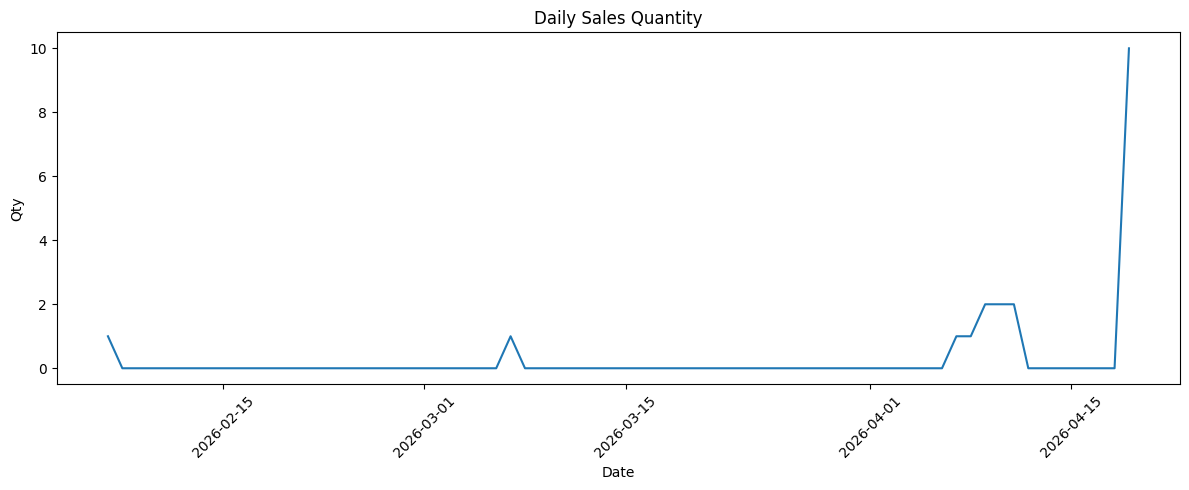

In [48]:
plt.figure()
plt.plot(daily_sales['Date'], daily_sales['Qty'])
plt.title('Daily Sales Quantity')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Feature engineering

In [49]:
feature_df = daily_sales.copy()

feature_df['day'] = feature_df['Date'].dt.day
feature_df['month'] = feature_df['Date'].dt.month
feature_df['year'] = feature_df['Date'].dt.year
feature_df['dayofweek'] = feature_df['Date'].dt.dayofweek
feature_df['weekofyear'] = feature_df['Date'].dt.isocalendar().week.astype(int)
feature_df['is_weekend'] = feature_df['dayofweek'].isin([5, 6]).astype(int)

# Lag features
feature_df['lag_1'] = feature_df['Qty'].shift(1)
feature_df['lag_2'] = feature_df['Qty'].shift(2)
feature_df['lag_3'] = feature_df['Qty'].shift(3)
feature_df['lag_7'] = feature_df['Qty'].shift(7)

# Rolling features
feature_df['rolling_mean_7'] = feature_df['Qty'].shift(1).rolling(7).mean()
feature_df['rolling_mean_14'] = feature_df['Qty'].shift(1).rolling(14).mean()
feature_df['rolling_std_7'] = feature_df['Qty'].shift(1).rolling(7).std()

feature_df = feature_df.dropna().reset_index(drop=True)
feature_df.head()

,Date,Qty,day,month,year,dayofweek,weekofyear,is_weekend,lag_1,lag_2,lag_3,lag_7,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2026-02-21,0,21,2,2026,5,8,1,0.0,0.0,0.0,0.0,0.0,0.071429,0.0
1,2026-02-22,0,22,2,2026,6,8,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,2026-02-23,0,23,2,2026,0,9,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,2026-02-24,0,24,2,2026,1,9,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,2026-02-25,0,25,2,2026,2,9,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


## 7. Train/test split

In [50]:
feature_cols = [
    'day', 'month', 'year', 'dayofweek', 'weekofyear', 'is_weekend',
    'lag_1', 'lag_2', 'lag_3', 'lag_7',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7'
]

X = feature_df[feature_cols]
y = feature_df['Qty']

split_index = int(len(feature_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = feature_df['Date'].iloc[split_index:]

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 46
Test size: 12


## 8. Train model

In [51]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 9. Evaluate model

In [52]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 1.45
RMSE : 2.97
R2   : -0.1920


In [53]:
results = pd.DataFrame({
    'Date': test_dates,
    'Actual_Qty': y_test.values,
    'Predicted_Qty': y_pred
})

results.head()

,Date,Actual_Qty,Predicted_Qty
46,2026-04-08,1,0.325224
47,2026-04-09,2,0.233954
48,2026-04-10,2,0.218065
49,2026-04-11,2,0.223176
50,2026-04-12,0,0.217509


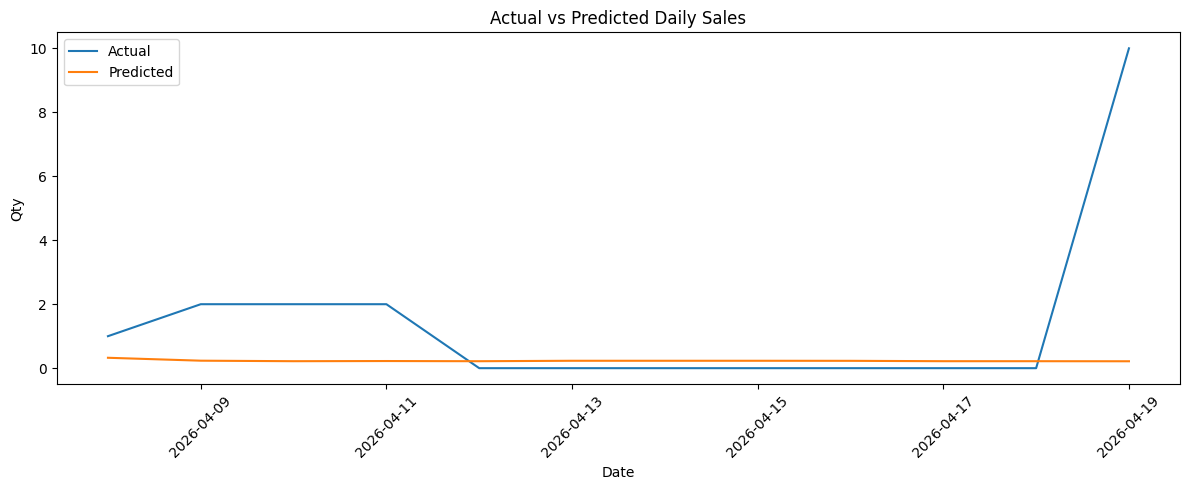

In [54]:
plt.figure()
plt.plot(results['Date'], results['Actual_Qty'], label='Actual')
plt.plot(results['Date'], results['Predicted_Qty'], label='Predicted')
plt.title('Actual vs Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Forecast next 7 days

In [55]:
forecast_days = 7
history = feature_df[['Date', 'Qty']].copy()
future_rows = []

for _ in range(forecast_days):
    next_date = history['Date'].max() + pd.Timedelta(days=1)

    next_row = {
        'Date': next_date,
        'day': next_date.day,
        'month': next_date.month,
        'year': next_date.year,
        'dayofweek': next_date.dayofweek,
        'weekofyear': int(next_date.isocalendar().week),
        'is_weekend': int(next_date.dayofweek in [5, 6]),
        'lag_1': history['Qty'].iloc[-1],
        'lag_2': history['Qty'].iloc[-2],
        'lag_3': history['Qty'].iloc[-3],
        'lag_7': history['Qty'].iloc[-7],
        'rolling_mean_7': history['Qty'].iloc[-7:].mean(),
        'rolling_mean_14': history['Qty'].iloc[-14:].mean(),
        'rolling_std_7': history['Qty'].iloc[-7:].std()
    }

    pred = model.predict(pd.DataFrame([next_row])[feature_cols])[0]
    pred = max(0, round(pred, 2))

    future_rows.append({'Date': next_date, 'Predicted_Qty': pred})
    history = pd.concat([history, pd.DataFrame([{'Date': next_date, 'Qty': pred}])], ignore_index=True)

future_df = pd.DataFrame(future_rows)
future_df

,Date,Predicted_Qty
0,2026-04-20,0.23
1,2026-04-21,0.23
2,2026-04-22,0.23
3,2026-04-23,0.23
4,2026-04-24,0.22
5,2026-04-25,0.22
6,2026-04-26,0.22


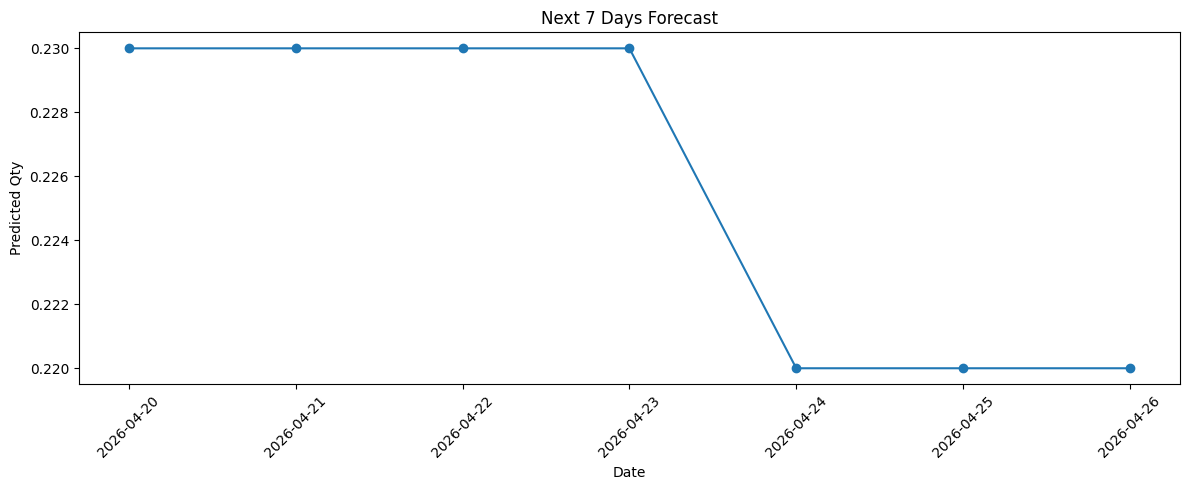

In [56]:
plt.figure()
plt.plot(future_df['Date'], future_df['Predicted_Qty'], marker='o')
plt.title('Next 7 Days Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Qty')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Export files

In [57]:
results.to_csv('model_test_predictions.csv', index=False)
future_df.to_csv('next_7_days_sales_forecast.csv', index=False)

print('Saved: model_test_predictions.csv')
print('Saved: next_7_days_sales_forecast.csv')

Saved: model_test_predictions.csv
Saved: next_7_days_sales_forecast.csv


## 12. Optional: Brand-wise prediction loop

Use this only if you want a separate model per brand.

In [58]:
brands = sorted(df['Brand'].dropna().unique())
print('Number of brands:', len(brands))
brands[:20]

Number of brands: 1


['OFFICERS CHOICE PRESTIGE WHISKY']

In [59]:
# Example framework for looping brand-wise
all_brand_forecasts = []

for brand_name in brands:
    temp = df[df['Brand'] == brand_name].groupby('Date', as_index=False)['Qty'].sum().sort_values('Date')
    if len(temp) < 30:
        continue

    full_dates = pd.date_range(temp['Date'].min(), temp['Date'].max(), freq='D')
    temp = temp.set_index('Date').reindex(full_dates, fill_value=0).rename_axis('Date').reset_index()

    temp['day'] = temp['Date'].dt.day
    temp['month'] = temp['Date'].dt.month
    temp['year'] = temp['Date'].dt.year
    temp['dayofweek'] = temp['Date'].dt.dayofweek
    temp['weekofyear'] = temp['Date'].dt.isocalendar().week.astype(int)
    temp['is_weekend'] = temp['dayofweek'].isin([5, 6]).astype(int)
    temp['lag_1'] = temp['Qty'].shift(1)
    temp['lag_2'] = temp['Qty'].shift(2)
    temp['lag_3'] = temp['Qty'].shift(3)
    temp['lag_7'] = temp['Qty'].shift(7)
    temp['rolling_mean_7'] = temp['Qty'].shift(1).rolling(7).mean()
    temp['rolling_mean_14'] = temp['Qty'].shift(1).rolling(14).mean()
    temp['rolling_std_7'] = temp['Qty'].shift(1).rolling(7).std()
    temp = temp.dropna().reset_index(drop=True)

    if len(temp) < 20:
        continue

    Xb = temp[feature_cols]
    yb = temp['Qty']
    model_b = RandomForestRegressor(n_estimators=200, random_state=42)
    model_b.fit(Xb, yb)

    hist = temp[['Date', 'Qty']].copy()
    next_date = hist['Date'].max() + pd.Timedelta(days=1)
    row = {
        'day': next_date.day,
        'month': next_date.month,
        'year': next_date.year,
        'dayofweek': next_date.dayofweek,
        'weekofyear': int(next_date.isocalendar().week),
        'is_weekend': int(next_date.dayofweek in [5, 6]),
        'lag_1': hist['Qty'].iloc[-1],
        'lag_2': hist['Qty'].iloc[-2],
        'lag_3': hist['Qty'].iloc[-3],
        'lag_7': hist['Qty'].iloc[-7],
        'rolling_mean_7': hist['Qty'].iloc[-7:].mean(),
        'rolling_mean_14': hist['Qty'].iloc[-14:].mean(),
        'rolling_std_7': hist['Qty'].iloc[-7:].std()
    }

    pred_b = model_b.predict(pd.DataFrame([row])[feature_cols])[0]
    all_brand_forecasts.append({
        'Brand': brand_name,
        'Forecast_Date': next_date,
        'Predicted_Qty': round(max(0, pred_b), 2)
    })

brand_forecast_df = pd.DataFrame(all_brand_forecasts)
brand_forecast_df.head()

""


In [60]:
if 'brand_forecast_df' in globals() and not brand_forecast_df.empty:
    brand_forecast_df.to_csv('brand_wise_next_day_forecast.csv', index=False)
    print('Saved: brand_wise_next_day_forecast.csv')
else:
    print('No brand-wise forecast generated.')

No brand-wise forecast generated.


## Notes

- This notebook uses `RandomForestRegressor` for an easy and practical start.
- For better forecasting, you can later try XGBoost, LightGBM, Prophet, or ARIMA.
- You can improve accuracy by adding:
  - stock availability
  - product price
  - holiday flags
  - promotion flags
  - month-end / weekend effects
  - incoming stock
